In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

df = pd.read_csv("../Telco-Customer-Churn-cleaned.csv")

c:\Users\Ashish\anaconda3\envs\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X=df.drop(columns=['Churn'])
Y=df['Churn']
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

best_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
best_model.fit(X_train, Y_train)
print("Model trained")

Model trained


c:\Users\Ashish\anaconda3\envs\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [4]:
#SHap explainer initialization
explainer=shap.LinearExplainer(best_model,X_train)
# shap val for test set
shap_values=explainer.shap_values(X_test)

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


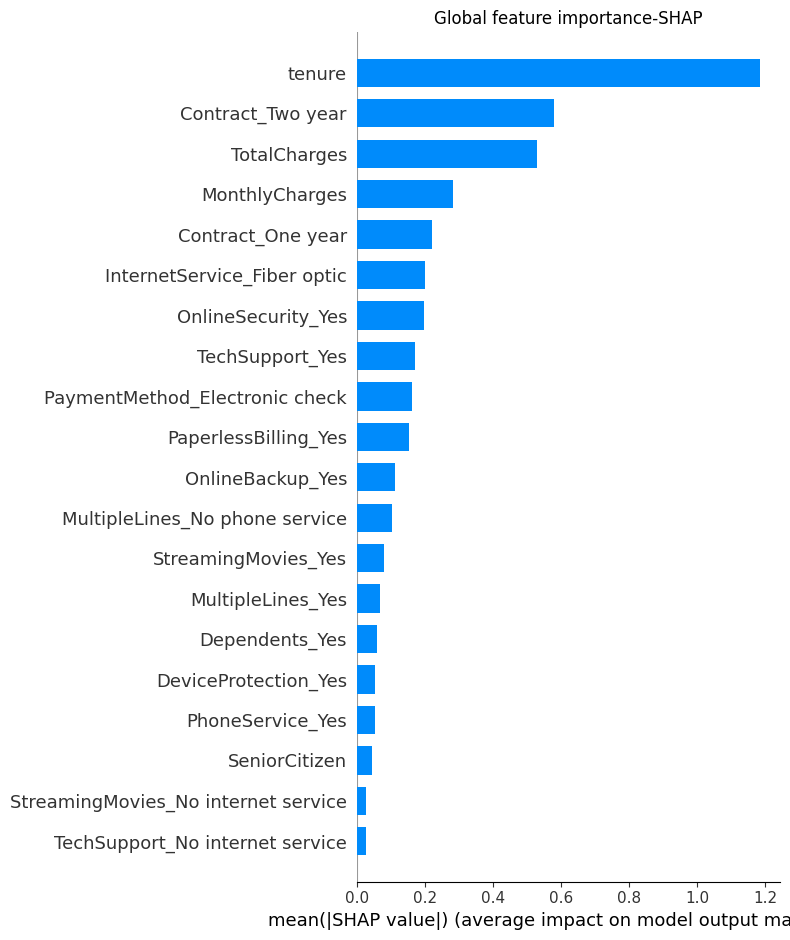

In [5]:
#global summary
plt.figure()
shap.summary_plot(shap_values,X_test,plot_type='bar',show=False)
plt.title("Global feature importance-SHAP")
plt.tight_layout()
plt.savefig('../outputs/plots/shap_global_summary.png')
plt.show()


In [6]:
#Highest risk
churn_probabilities=best_model.predict_proba(X_test)[:, 1]


highest_risk_idx=np.argmax(churn_probabilities)
highest_risk_prob=churn_probabilities[highest_risk_idx]

print(f"Highest risk customer index:{highest_risk_idx}")
print(f"Churn probability:{highest_risk_prob:.2%}")
print(f"\nCustomer profile:")
print(X_test.iloc[highest_risk_idx])

Highest risk customer index:1109
Churn probability:93.00%

Customer profile:
SeniorCitizen                              1.0
tenure                                     1.0
MonthlyCharges                           100.8
TotalCharges                             100.8
gender_Male                                0.0
Partner_Yes                                1.0
Dependents_Yes                             0.0
PhoneService_Yes                           1.0
MultipleLines_No phone service             0.0
MultipleLines_Yes                          1.0
InternetService_Fiber optic                1.0
InternetService_No                         0.0
OnlineSecurity_No internet service         0.0
OnlineSecurity_Yes                         0.0
OnlineBackup_No internet service           0.0
OnlineBackup_Yes                           0.0
DeviceProtection_No internet service       0.0
DeviceProtection_Yes                       1.0
TechSupport_No internet service            0.0
TechSupport_Yes               

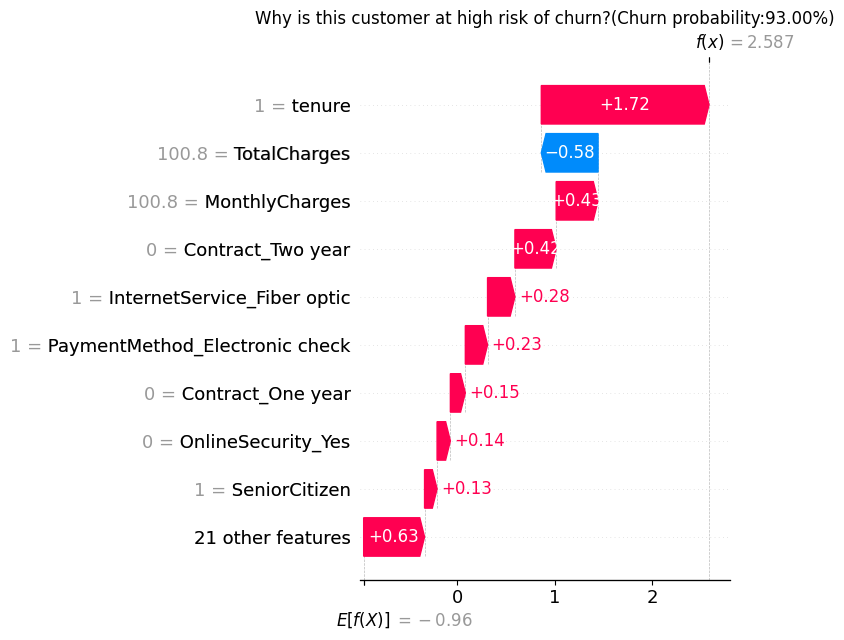

In [7]:
explaination=shap.Explanation(values=shap_values[highest_risk_idx],
                              base_values=explainer.expected_value,
                              data=X_test.iloc[highest_risk_idx].values,
                              feature_names=X_test.columns.tolist())
plt.figure()
shap.plots.waterfall(explaination,show=False)
plt.title(f"Why is this customer at high risk of churn?(Churn probability:{highest_risk_prob:.2%})")
plt.tight_layout()
plt.savefig('../outputs/plots/shap_waterfall_highest_risk.png',bbox_inches='tight')
plt.show()

<Figure size 1000x600 with 0 Axes>

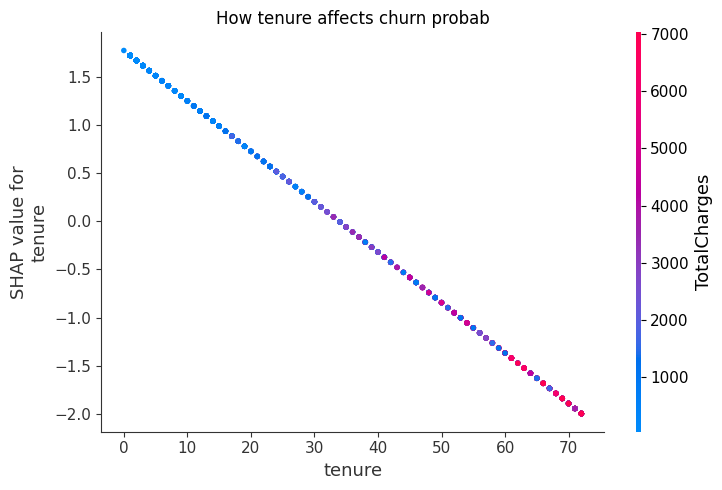

In [8]:
tenure_idx=X_test.columns.tolist().index('tenure')

plt.figure(figsize=(10,6))
shap.dependence_plot(
    tenure_idx,shap_values,X_test,show=False
)
plt.title("How tenure affects churn probab")
plt.tight_layout()
plt.savefig('../outputs/plots/shap_dependence_tenure.png')
plt.show()

In [9]:
# score all customers not just test set
full_df = df.drop(columns=['Churn'])
all_probabilities = best_model.predict_proba(full_df)[:, 1]

risk_df = df.copy()
risk_df['churn_probability'] = all_probabilities
risk_df = risk_df.sort_values('churn_probability', ascending=False)

top_100 = risk_df.head(100)
top_100.to_csv('../outputs/top_100_high_risk_customers.csv', index=False)

In [10]:
risk_df['revenue_at_risk']=risk_df['churn_probability']*risk_df['MonthlyCharges']

total_revenue_at_risk=risk_df['revenue_at_risk'].sum()
top_100_revenue_at_risk=risk_df.head(100)['revenue_at_risk'].sum()

print(f"Total revenue at risk:${total_revenue_at_risk:,.2f}")
print(f"Top 100 revenue at risk:${top_100_revenue_at_risk:,.2f}")

risk_df.to_csv('../outputs/full_risk_scores.csv',index=False)
print("\nFull risk scores saved for Power BI")

Total revenue at risk:$213,132.53
Top 100 revenue at risk:$8,405.47

Full risk scores saved for Power BI


In [11]:
shap_importance=pd.DataFrame({
    'feature':X_test.columns.tolist(),
    'shap_importance':np.abs(shap_values).mean(axis=0)
})
shap_importance=shap_importance.sort_values('shap_importance',ascending=False)

shap_importance.to_csv('../outputs/shap_feature_importance.csv',index=False)

In [12]:
observations = """
Week 3 - SHAP Findings:
1. Top global features - tenure, MonthlyCharges, Contract type (consistent with EDA)
2. Highest risk customer has X% churn probability
3. Key drivers for high risk customer - (fill after seeing waterfall plot)
4. Tenure dependence plot confirms - longer tenure = lower churn contribution
5. Total revenue at risk = ₹X across test set
"""
print(observations)


Week 3 - SHAP Findings:
1. Top global features - tenure, MonthlyCharges, Contract type (consistent with EDA)
2. Highest risk customer has X% churn probability
3. Key drivers for high risk customer - (fill after seeing waterfall plot)
4. Tenure dependence plot confirms - longer tenure = lower churn contribution
5. Total revenue at risk = ₹X across test set

